In [1]:
import os
import gc
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [4]:
DATASET_ROOT = Path("PBC_balanced_notebook")

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

print("Train dir:", TRAIN_DIR)
print("Validation dir:", VAL_DIR)
print("Test dir:", TEST_DIR)

assert TRAIN_DIR.exists(), f"Could not find train directory: {TRAIN_DIR}"
assert VAL_DIR.exists(), f"Could not find validation directory: {VAL_DIR}"
assert TEST_DIR.exists(), f"Could not find test directory: {TEST_DIR}"

Train dir: PBC_balanced_notebook/train
Validation dir: PBC_balanced_notebook/val
Test dir: PBC_balanced_notebook/test


In [6]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def build_dataframe_from_folder(folder_path: Path):
    rows = []

    class_dirs = sorted([
        d for d in folder_path.iterdir()
        if d.is_dir()
    ])

    for class_dir in class_dirs:
        class_label = class_dir.name

        for image_path in class_dir.rglob("*"):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTS:
                rows.append({
                    "image_path": str(image_path),
                    "class_label": class_label
                })

    df = pd.DataFrame(rows)

    if len(df) == 0:
        raise RuntimeError(f"Images not found: {folder_path}")

    return df


train_df = build_dataframe_from_folder(TRAIN_DIR)
val_df = build_dataframe_from_folder(VAL_DIR)
test_df = build_dataframe_from_folder(TEST_DIR)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

Train shape: (18640, 2)
Validation shape: (1710, 2)
Test shape: (3419, 2)


,image_path,class_label
0,PBC_balanced_notebook/train/basophil/BA_127671...,basophil
1,PBC_balanced_notebook/train/basophil/BA_909453...,basophil
2,PBC_balanced_notebook/train/basophil/BA_363451...,basophil
3,PBC_balanced_notebook/train/basophil/BA_366588...,basophil
4,PBC_balanced_notebook/train/basophil/BA_622087...,basophil


In [7]:
class_names = sorted(train_df["class_label"].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

train_df["label"] = train_df["class_label"].map(class_to_idx)
val_df["label"] = val_df["class_label"].map(class_to_idx)
test_df["label"] = test_df["class_label"].map(class_to_idx)

NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)
print("Class mapping:")

for idx, class_name in idx_to_class.items():
    print(idx, ":", class_name)

display(train_df.head())

Number of classes: 8
Class mapping:
0 : basophil
1 : eosinophil
2 : erythroblast
3 : ig
4 : lymphocyte
5 : monocyte
6 : neutrophil
7 : platelet


,image_path,class_label,label
0,PBC_balanced_notebook/train/basophil/BA_127671...,basophil,0
1,PBC_balanced_notebook/train/basophil/BA_909453...,basophil,0
2,PBC_balanced_notebook/train/basophil/BA_363451...,basophil,0
3,PBC_balanced_notebook/train/basophil/BA_366588...,basophil,0
4,PBC_balanced_notebook/train/basophil/BA_622087...,basophil,0


,Class,Image Count,Percentage
0,basophil,2330,12.5
1,eosinophil,2330,12.5
2,erythroblast,2330,12.5
3,ig,2330,12.5
4,lymphocyte,2330,12.5
5,monocyte,2330,12.5
6,neutrophil,2330,12.5
7,platelet,2330,12.5


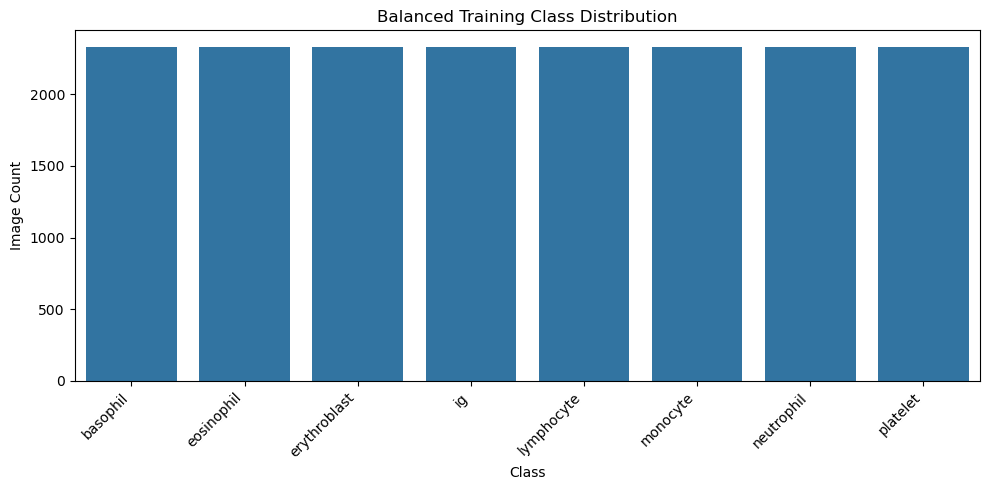

In [8]:
class_counts = train_df["class_label"].value_counts().sort_values(ascending=False)

class_counts_df = class_counts.reset_index()
class_counts_df.columns = ["Class", "Image Count"]

class_counts_df["Percentage"] = (
    class_counts_df["Image Count"] / class_counts_df["Image Count"].sum() * 100
).round(2)

display(class_counts_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=class_counts_df, x="Class", y="Image Count")
plt.xticks(rotation=45, ha="right")
plt.title("Balanced Training Class Distribution")
plt.tight_layout()
plt.show()

In [9]:
train_df_balanced = train_df.copy()

print("Balanced train dataframe shape:", train_df_balanced.shape)
display(train_df_balanced["class_label"].value_counts().sort_index())

Balanced train dataframe shape: (18640, 3)


class_label
basophil        2330
eosinophil      2330
erythroblast    2330
ig              2330
lymphocyte      2330
monocyte        2330
neutrophil      2330
platelet        2330
Name: count, dtype: int64

In [10]:
IMG_SIZE = 224

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=12),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.06, 0.06),
        scale=(0.92, 1.08),
        shear=5
    ),
    transforms.ColorJitter(
        brightness=0.08,
        contrast=0.08,
        saturation=0.06,
        hue=0.02
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

In [11]:
class PBCDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = row["image_path"]
        label = int(row["label"])

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [12]:
BATCH_SIZE = 32

if os.name == "nt":
    NUM_WORKERS = 0
else:
    NUM_WORKERS = 2

train_dataset = PBCDataset(train_df_balanced, transform=train_transforms)
val_dataset = PBCDataset(val_df, transform=val_test_transforms)
test_dataset = PBCDataset(test_df, transform=val_test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda")
)

print("Batch size:", BATCH_SIZE)
print("Num workers:", NUM_WORKERS)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Batch size: 32
Num workers: 2
Training batches: 582
Validation batches: 54
Test batches: 107


In [13]:
classes = np.array(sorted(train_df_balanced["label"].unique()))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df_balanced["label"].values
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

class_weight_df = pd.DataFrame({
    "Class Index": classes,
    "Class": [idx_to_class[int(i)] for i in classes],
    "Class Weight": class_weights
})

display(class_weight_df)

,Class Index,Class,Class Weight
0,0,basophil,1.0
1,1,eosinophil,1.0
2,2,erythroblast,1.0
3,3,ig,1.0
4,4,lymphocyte,1.0
5,5,monocyte,1.0
6,6,neutrophil,1.0
7,7,platelet,1.0


In [14]:
class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x

        keep_prob = 1.0 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)

        random_tensor = keep_prob + torch.rand(
            shape,
            dtype=x.dtype,
            device=x.device
        )

        random_tensor.floor_()

        return x.div(keep_prob) * random_tensor


class ConvBNAct(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=1,
        groups=1,
        activation=True
    ):
        super().__init__()

        padding = kernel_size // 2

        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            groups=groups,
            bias=False
        )

        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU(inplace=True) if activation else nn.Identity()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.act(x)
        return x


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()

        hidden_channels = max(channels // reduction, 8)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=1),
            nn.SiLU(inplace=True),
            nn.Conv2d(hidden_channels, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale


class MBConvSEBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1,
        expansion=4,
        se_reduction=8,
        drop_path=0.0
    ):
        super().__init__()

        hidden_channels = in_channels * expansion
        self.use_residual = stride == 1 and in_channels == out_channels

        self.expand = ConvBNAct(
            in_channels,
            hidden_channels,
            kernel_size=1,
            stride=1
        )

        self.depthwise = ConvBNAct(
            hidden_channels,
            hidden_channels,
            kernel_size=3,
            stride=stride,
            groups=hidden_channels
        )

        self.se = SEBlock(
            hidden_channels,
            reduction=se_reduction
        )

        self.project = ConvBNAct(
            hidden_channels,
            out_channels,
            kernel_size=1,
            stride=1,
            activation=False
        )

        self.drop_path = DropPath(drop_path)

    def forward(self, x):
        identity = x

        out = self.expand(x)
        out = self.depthwise(out)
        out = self.se(out)
        out = self.project(out)

        if self.use_residual:
            out = self.drop_path(out)
            out = out + identity

        return out


class PBCNetSEMBConv(nn.Module):
    def __init__(self, num_classes=8, drop_rate=0.4, drop_path_rate=0.12):
        super().__init__()

        self.stem = nn.Sequential(
            ConvBNAct(3, 32, kernel_size=3, stride=2),
            ConvBNAct(32, 32, kernel_size=3, stride=1),
            ConvBNAct(32, 64, kernel_size=3, stride=2)
        )

        block_settings = [
            # out_channels, num_blocks, stride, expansion
            (64,  2, 1, 2),
            (96,  3, 2, 4),
            (160, 4, 2, 4),
            (256, 4, 2, 4),
            (384, 2, 1, 4)
        ]

        total_blocks = sum([s[1] for s in block_settings])
        block_id = 0

        stages = []
        in_channels = 64

        for out_channels, num_blocks, stride, expansion in block_settings:
            blocks = []

            for i in range(num_blocks):
                block_stride = stride if i == 0 else 1
                current_drop_path = drop_path_rate * block_id / max(total_blocks - 1, 1)

                blocks.append(
                    MBConvSEBlock(
                        in_channels=in_channels,
                        out_channels=out_channels,
                        stride=block_stride,
                        expansion=expansion,
                        se_reduction=8,
                        drop_path=current_drop_path
                    )
                )

                in_channels = out_channels
                block_id += 1

            stages.append(nn.Sequential(*blocks))

        self.stages = nn.Sequential(*stages)

        self.head = nn.Sequential(
            ConvBNAct(384, 512, kernel_size=1, stride=1),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=drop_rate),
            nn.Linear(512, 256),
            nn.SiLU(inplace=True),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(
                    module.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)
            elif isinstance(module, nn.BatchNorm1d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Linear):
                nn.init.trunc_normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stages(x)
        x = self.head(x)
        return x

In [15]:
MODEL_NAME = "PBCNet-SE-MBConv"

model = PBCNetSEMBConv(
    num_classes=NUM_CLASSES,
    drop_rate=0.2,
    drop_path_rate=0.12
)

model = model.to(DEVICE)

print(MODEL_NAME, "model has been created.")

PBCNet-SE-MBConv model has been created.


In [16]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = total_params - trainable_params

    return total_params, trainable_params, non_trainable_params


total_params, trainable_params, non_trainable_params = count_parameters(model)

print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")
print("Non-trainable parameters:", f"{non_trainable_params:,}")

Total parameters: 7,296,888
Trainable parameters: 7,296,888
Non-trainable parameters: 0


In [17]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=0.05
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

/tmp/ipykernel_133473/101407422.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


In [18]:
def copy_state_dict_to_cpu(model):
    return {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }

In [19]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, scaler):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "balanced_accuracy": epoch_bal_acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }


def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation", leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "balanced_accuracy": epoch_bal_acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

In [20]:
EPOCHS = 50
PATIENCE = 12

best_val_f1 = -np.inf
best_epoch = 0
epochs_without_improvement = 0

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "train_balanced_accuracy": [],
    "val_balanced_accuracy": [],
    "train_macro_f1": [],
    "val_macro_f1": []
}

best_model_wts = copy_state_dict_to_cpu(model)

start_training_time = time.time()

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print("-" * 40)

    train_metrics = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        scaler=scaler
    )

    val_metrics = validate_one_epoch(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=DEVICE
    )

    scheduler.step(val_metrics["loss"])

    history["epoch"].append(epoch)
    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_accuracy"].append(train_metrics["accuracy"])
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["train_balanced_accuracy"].append(train_metrics["balanced_accuracy"])
    history["val_balanced_accuracy"].append(val_metrics["balanced_accuracy"])
    history["train_macro_f1"].append(train_metrics["macro_f1"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])

    print(
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Accuracy: {train_metrics['accuracy']:.4f} | "
        f"Train Macro-F1: {train_metrics['macro_f1']:.4f}"
    )

    print(
        f"Validation Loss: {val_metrics['loss']:.4f} | "
        f"Validation Accuracy: {val_metrics['accuracy']:.4f} | "
        f"Validation Macro-F1: {val_metrics['macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        best_epoch = epoch
        epochs_without_improvement = 0
        best_model_wts = copy_state_dict_to_cpu(model)

        print("New best model has been saved.")

    else:
        epochs_without_improvement += 1
        print("No improvement count:", epochs_without_improvement)

    if DEVICE.type == "cuda":
        allocated_memory = torch.cuda.memory_allocated() / (1024 ** 2)
        reserved_memory = torch.cuda.memory_reserved() / (1024 ** 2)

        print(f"GPU allocated memory in MB: {allocated_memory:.2f}")
        print(f"GPU reserved memory in MB: {reserved_memory:.2f}")

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping has been applied.")
        break

total_training_time = time.time() - start_training_time

model.load_state_dict(best_model_wts)
model = model.to(DEVICE)

print("\nTraining has been completed.")
print("Best epoch:", best_epoch)
print("Best validation Macro-F1:", round(best_val_f1, 4))
print("Total training time in seconds:", round(total_training_time, 2))
print("Total training time in minutes:", round(total_training_time / 60, 2))


Epoch 1/50
----------------------------------------


Training:   0%|          | 0/582 [00:00<?, ?it/s]/tmp/ipykernel_133473/412373049.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
Validation:   0%|          | 0/54 [00:00<?, ?it/s]         /tmp/ipykernel_133473/412373049.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Train Loss: 1.1521 | Train Accuracy: 0.6155 | Train Macro-F1: 0.6078
Validation Loss: 0.6069 | Validation Accuracy: 0.8427 | Validation Macro-F1: 0.8074
New best model has been saved.
GPU allocated memory in MB: 129.50
GPU reserved memory in MB: 310.00

Epoch 2/50
----------------------------------------


Training:   0%|          | 0/582 [00:00<?, ?it/s]/tmp/ipykernel_133473/412373049.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
Validation:   0%|          | 0/54 [00:00<?, ?it/s]         /tmp/ipykernel_133473/412373049.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Train Loss: 0.6515 | Train Accuracy: 0.8504 | Train Macro-F1: 0.8497
Validation Loss: 0.4303 | Validation Accuracy: 0.9374 | Validation Macro-F1: 0.9307
New best model has been saved.
GPU allocated memory in MB: 129.99
GPU reserved memory in MB: 1844.00

Epoch 3/50
----------------------------------------


...

Train Loss: 0.2829 | Train Accuracy: 0.9951 | Train Macro-F1: 0.9951
Validation Loss: 0.3167 | Validation Accuracy: 0.9819 | Validation Macro-F1: 0.9847
No improvement count: 10
GPU allocated memory in MB: 130.38
GPU reserved memory in MB: 1856.00

Epoch 44/50
----------------------------------------


Training:   0%|          | 0/582 [00:00<?, ?it/s]/tmp/ipykernel_133473/412373049.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
Validation:   0%|          | 0/54 [00:00<?, ?it/s]         /tmp/ipykernel_133473/412373049.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Train Loss: 0.2829 | Train Accuracy: 0.9951 | Train Macro-F1: 0.9951
Validation Loss: 0.3108 | Validation Accuracy: 0.9830 | Validation Macro-F1: 0.9857
No improvement count: 11
GPU allocated memory in MB: 129.74
GPU reserved memory in MB: 1848.00

Epoch 45/50
----------------------------------------


Training:   0%|          | 0/582 [00:00<?, ?it/s]/tmp/ipykernel_133473/412373049.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
Validation:   0%|          | 0/54 [00:00<?, ?it/s]         /tmp/ipykernel_133473/412373049.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Train Loss: 0.2854 | Train Accuracy: 0.9943 | Train Macro-F1: 0.9943
Validation Loss: 0.3098 | Validation Accuracy: 0.9836 | Validation Macro-F1: 0.9864
No improvement count: 12
GPU allocated memory in MB: 130.13
GPU reserved memory in MB: 1854.00
Early stopping has been applied.

Training has been completed.
Best epoch: 33
Best validation Macro-F1: 0.9871
Total training time in seconds: 3422.25
Total training time in minutes: 57.04


,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_balanced_accuracy,val_balanced_accuracy,train_macro_f1,val_macro_f1
0,1,1.152080,0.606879,0.615496,0.842690,0.615517,0.803255,0.607821,0.807391
1,2,0.651473,0.430257,0.850408,0.937427,0.850384,0.928472,0.849692,0.930657
2,3,0.535402,0.448711,0.896585,0.921637,0.896591,0.923862,0.896367,0.911362
3,4,0.481805,0.476362,0.918224,0.912865,0.918212,0.925690,0.918124,0.908073
4,5,0.443648,0.336601,0.935406,0.971345,0.935401,0.968715,0.935376,0.970781
5,6,0.434923,0.367477,0.938574,0.956725,0.938583,0.942781,0.938553,0.952194
6,7,0.410752,0.349869,0.950387,0.964327,0.950380,0.966688,0.950358,0.965748
7,8,0.397722,0.348194,0.952266,0.971345,0.952267,0.967038,0.952292,0.969513
8,9,0.385649,0.369450,0.956454,0.958480,0.956451,0.953428,0.956441,0.954625
9,10,0.351836,0.326978,0.970522,0.977193,0.970513,0.975680,0.970515,0.978585


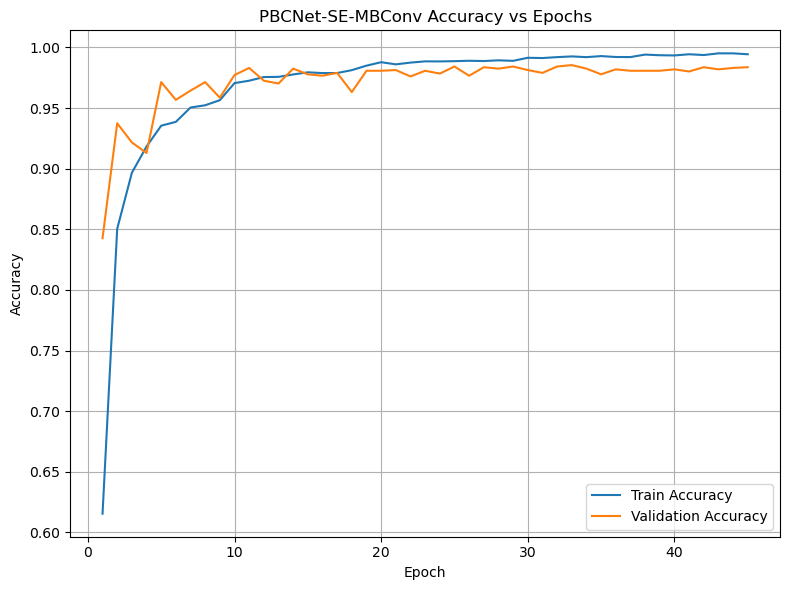

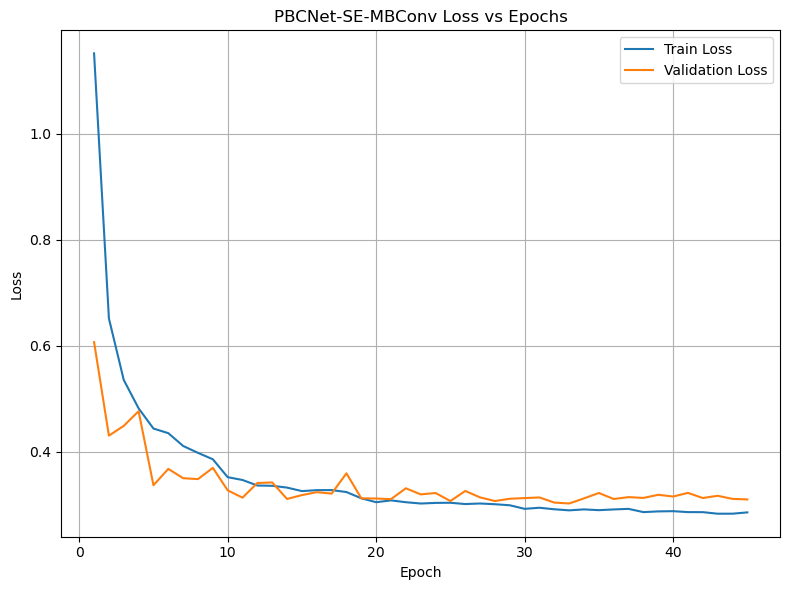

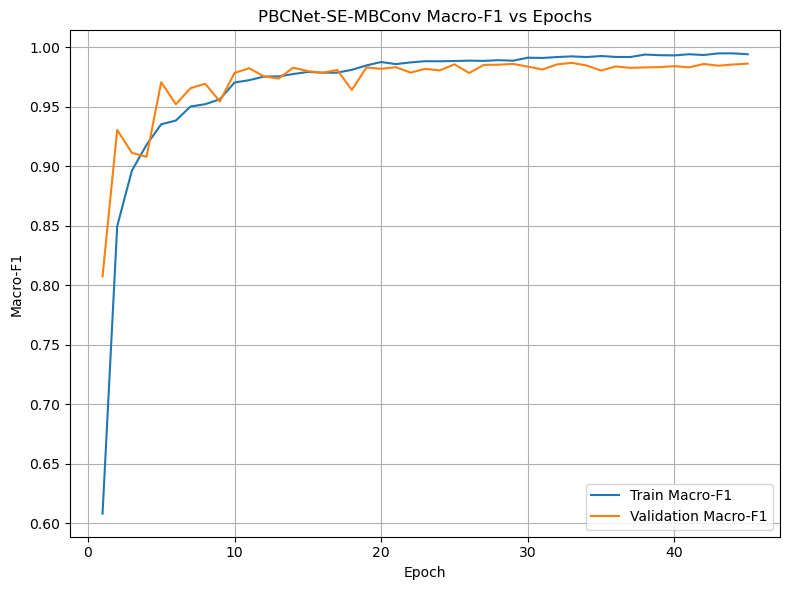

In [21]:
history_df = pd.DataFrame(history)

display(history_df)

plt.figure(figsize=(8, 6))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("PBCNet-SE-MBConv Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PBCNet-SE-MBConv Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="Train Macro-F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Validation Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("PBCNet-SE-MBConv Macro-F1 vs Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
def evaluate_model(model, dataloader, device, num_classes):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    inference_start = time.time()

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Testing"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                outputs = model(images)
                probs = torch.softmax(outputs, dim=1)

            preds = torch.argmax(probs, dim=1)

            all_labels.extend(labels.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())

    inference_time = time.time() - inference_start

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    accuracy = accuracy_score(all_labels, all_preds)
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    y_true_bin = label_binarize(all_labels, classes=list(range(num_classes)))

    try:
        roc_auc_macro = roc_auc_score(
            y_true_bin,
            all_probs,
            average="macro",
            multi_class="ovr"
        )

        roc_auc_weighted = roc_auc_score(
            y_true_bin,
            all_probs,
            average="weighted",
            multi_class="ovr"
        )

    except ValueError:
        roc_auc_macro = np.nan
        roc_auc_weighted = np.nan

    metrics = {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "roc_auc_macro": roc_auc_macro,
        "roc_auc_weighted": roc_auc_weighted,
        "total_inference_time_sec": inference_time,
        "avg_inference_time_per_image_ms": inference_time / len(dataloader.dataset) * 1000,
        "throughput_images_per_sec": len(dataloader.dataset) / inference_time
    }

    return metrics, all_labels, all_preds, all_probs

In [23]:
test_metrics, y_true, y_pred, y_prob = evaluate_model(
    model=model,
    dataloader=test_loader,
    device=DEVICE,
    num_classes=NUM_CLASSES
)

test_metrics_df = pd.DataFrame(
    list(test_metrics.items()),
    columns=["Metric", "Value"]
)

display(test_metrics_df)

Testing:   0%|          | 0/107 [00:00<?, ?it/s]/tmp/ipykernel_133473/869839169.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
Testing: 100%|██████████| 107/107 [00:12<00:00,  8.42it/s]


,Metric,Value
0,accuracy,0.989763
1,balanced_accuracy,0.989723
2,macro_precision,0.990592
3,macro_recall,0.989723
4,macro_f1,0.990116
5,weighted_precision,0.989819
6,weighted_recall,0.989763
7,weighted_f1,0.989762
8,roc_auc_macro,0.999796
9,roc_auc_weighted,0.999730


In [24]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

,precision,recall,f1-score,support
basophil,1.000000,0.995902,0.997947,244.000000
eosinophil,1.000000,1.000000,1.000000,623.000000
erythroblast,1.000000,0.987097,0.993506,310.000000
ig,0.977470,0.974093,0.975779,579.000000
lymphocyte,0.975904,1.000000,0.987805,243.000000
monocyte,0.992806,0.971831,0.982206,284.000000
neutrophil,0.980684,0.990991,0.985810,666.000000
platelet,0.997872,0.997872,0.997872,470.000000
accuracy,0.989763,0.989763,0.989763,0.989763
macro avg,0.990592,0.989723,0.990116,3419.000000


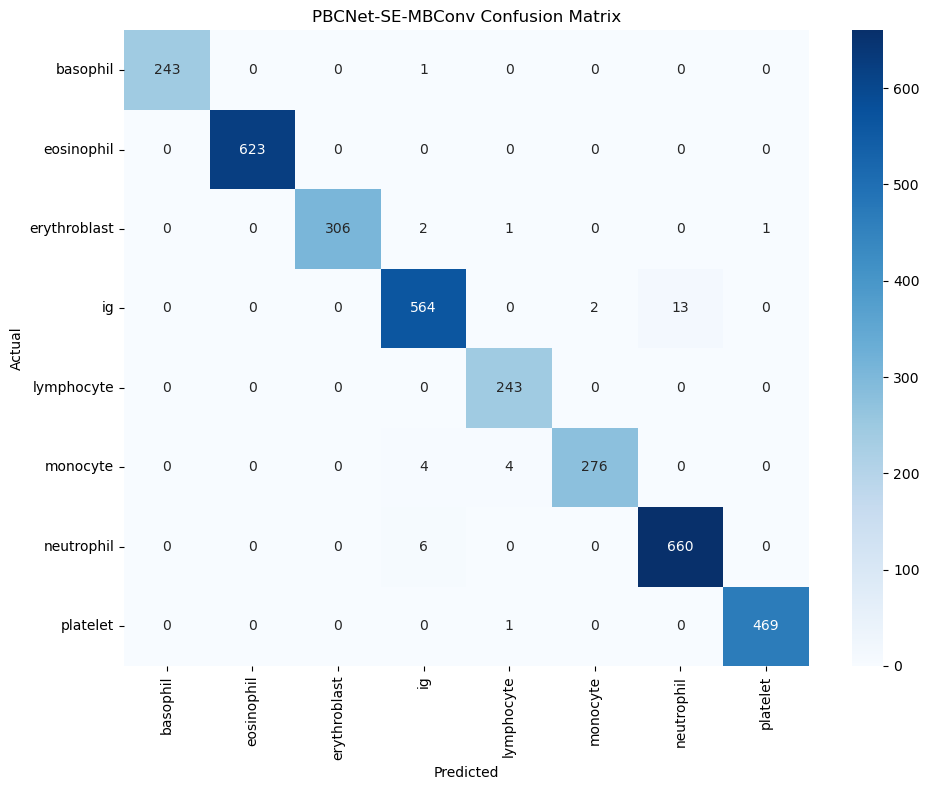

In [25]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("PBCNet-SE-MBConv Confusion Matrix")
plt.tight_layout()
plt.show()

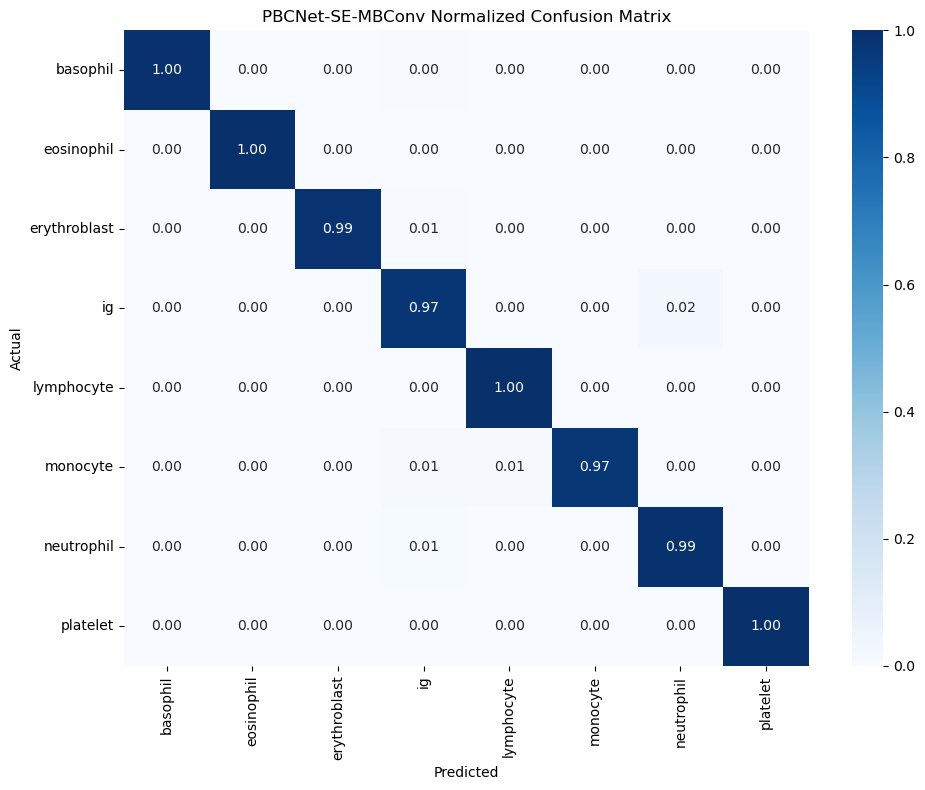

In [26]:
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("PBCNet-SE-MBConv Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

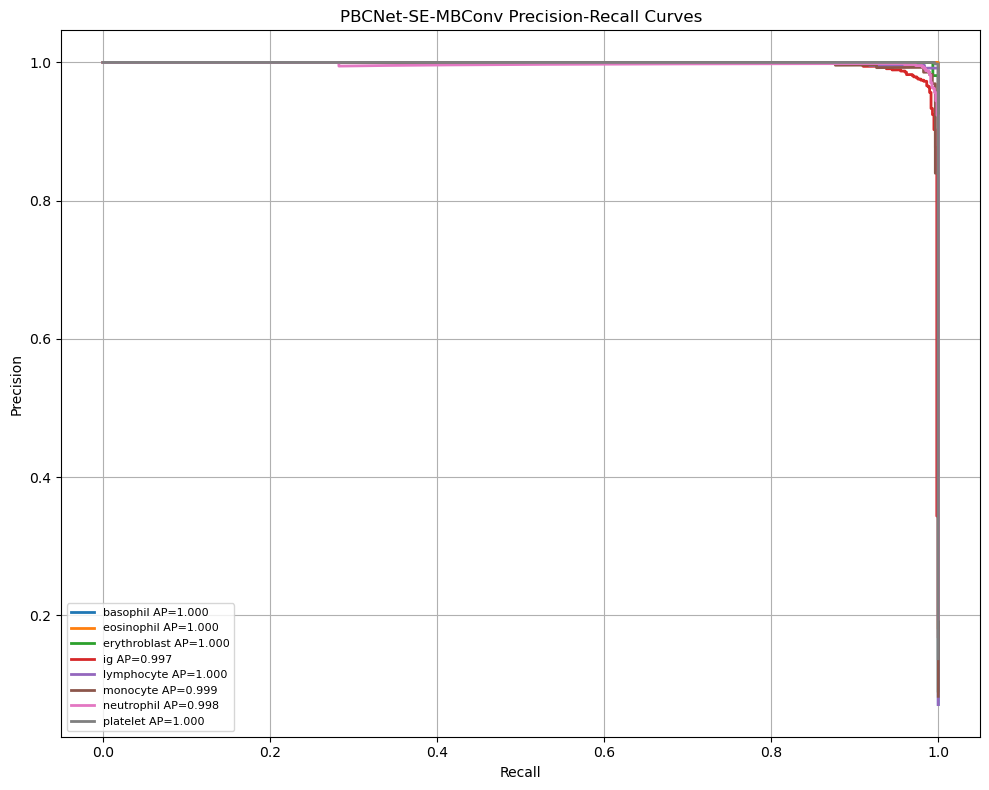

Macro-average precision score: 0.9991


In [27]:
y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))

precision = {}
recall = {}
average_precision = {}

plt.figure(figsize=(10, 8))

for i in range(NUM_CLASSES):
    precision[i], recall[i], _ = precision_recall_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    average_precision[i] = average_precision_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(
        recall[i],
        precision[i],
        lw=2,
        label=f"{class_names[i]} AP={average_precision[i]:.3f}"
    )

macro_average_precision = np.mean(list(average_precision.values()))

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PBCNet-SE-MBConv Precision-Recall Curves")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

print("Macro-average precision score:", round(macro_average_precision, 4))

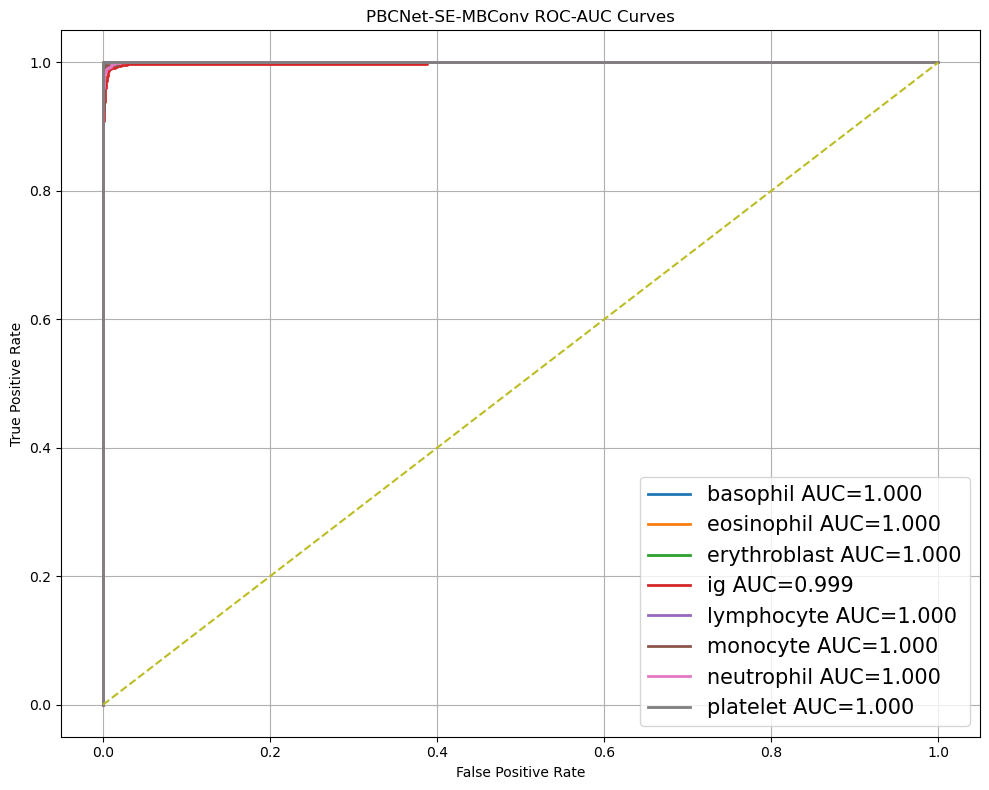

Macro-average ROC-AUC score: 0.9998


In [34]:
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

    plt.plot(
        fpr[i],
        tpr[i],
        lw=2,
        label=f"{class_names[i]} AUC={roc_auc[i]:.3f}"
    )

macro_average_auc = np.mean(list(roc_auc.values()))

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("PBCNet-SE-MBConv ROC-AUC Curves")
plt.legend(fontsize=15)
plt.grid(True)
plt.tight_layout()
plt.show()

print("Macro-average ROC-AUC score:", round(macro_average_auc, 4))

In [29]:
def tta_predict_pbc_pytorch(image_path, model, device):
    model.eval()

    original_image = Image.open(image_path).convert("RGB")
    original_image = original_image.resize((IMG_SIZE, IMG_SIZE))

    tta_images = [
        original_image,
        original_image.transpose(Image.FLIP_LEFT_RIGHT),
        original_image.transpose(Image.FLIP_TOP_BOTTOM),
        original_image.rotate(90)
    ]

    tta_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    batch = torch.stack([
        tta_transform(img) for img in tta_images
    ]).to(device)

    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(batch)
            probs = torch.softmax(outputs, dim=1)

    avg_prob = probs.mean(dim=0).detach().cpu().numpy()

    predicted_class_index = int(np.argmax(avg_prob))
    predicted_label = class_names[predicted_class_index]
    confidence_score = avg_prob[predicted_class_index] * 100

    return predicted_label, confidence_score, avg_prob

/tmp/ipykernel_133473/665755007.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


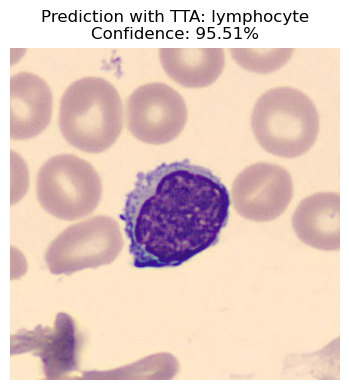

True label: lymphocyte
Predicted label: lymphocyte
Confidence: 95.51


In [30]:
sample_row = test_df.sample(1, random_state=SEED).iloc[0]
sample_image_path = sample_row["image_path"]

predicted_label, confidence_score, avg_prob = tta_predict_pbc_pytorch(
    image_path=sample_image_path,
    model=model,
    device=DEVICE
)

plt.figure(figsize=(4, 4))
img = Image.open(sample_image_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction with TTA: {predicted_label}\nConfidence: {confidence_score:.2f}%")
plt.tight_layout()
plt.show()

print("True label:", sample_row["class_label"])
print("Predicted label:", predicted_label)
print("Confidence:", round(confidence_score, 2))

In [31]:
results_dir = Path("model_results_pytorch/pbcnet_se_mbconv")
results_dir.mkdir(parents=True, exist_ok=True)

model_path = results_dir / "pbcnet_se_mbconv_best.pth"

torch.save(
    {
        "model_name": MODEL_NAME,
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "class_to_idx": class_to_idx,
        "idx_to_class": idx_to_class,
        "num_classes": NUM_CLASSES,
        "img_size": IMG_SIZE,
        "imagenet_mean": imagenet_mean,
        "imagenet_std": imagenet_std,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_val_f1,
        "total_params": total_params,
        "trainable_params": trainable_params,
        "non_trainable_params": non_trainable_params
    },
    model_path
)

history_df.to_csv(results_dir / "training_history.csv", index=False)
test_metrics_df.to_csv(results_dir / "test_metrics.csv", index=False)
report_df.to_csv(results_dir / "classification_report.csv")

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(results_dir / "confusion_matrix.csv")

cm_norm_df = pd.DataFrame(cm_normalized, index=class_names, columns=class_names)
cm_norm_df.to_csv(results_dir / "confusion_matrix_normalized.csv")

print("PBCNet-SE-MBConv model weights and results have been saved to:", results_dir)
print("Model checkpoint:", model_path)

PBCNet-SE-MBConv model weights and results have been saved to: model_results_pytorch/pbcnet_se_mbconv
Model checkpoint: model_results_pytorch/pbcnet_se_mbconv/pbcnet_se_mbconv_best.pth


In [32]:
model_size_mb = os.path.getsize(model_path) / (1024 ** 2)

max_gpu_memory_mb = None

if DEVICE.type == "cuda":
    max_gpu_memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

summary_row = {
    "Model": MODEL_NAME,
    "Accuracy": test_metrics["accuracy"],
    "Balanced Accuracy": test_metrics["balanced_accuracy"],
    "Macro Precision": test_metrics["macro_precision"],
    "Macro Recall": test_metrics["macro_recall"],
    "Macro F1": test_metrics["macro_f1"],
    "Weighted F1": test_metrics["weighted_f1"],
    "ROC AUC Macro": test_metrics["roc_auc_macro"],
    "Average Precision Macro": macro_average_precision,
    "Total Parameters": total_params,
    "Trainable Parameters": trainable_params,
    "Non-trainable Parameters": non_trainable_params,
    "Model Size MB": model_size_mb,
    "Best Epoch": best_epoch,
    "Best Validation Macro F1": best_val_f1,
    "Training Time Min": total_training_time / 60,
    "Inference Time per Image ms": test_metrics["avg_inference_time_per_image_ms"],
    "Throughput Images per Sec": test_metrics["throughput_images_per_sec"],
    "Max GPU Memory MB": max_gpu_memory_mb
}

pbcnet_summary_df = pd.DataFrame([summary_row])

display(pbcnet_summary_df)

pbcnet_summary_df.to_csv(
    results_dir / "pbcnet_se_mbconv_summary.csv",
    index=False
)

print("All PBCNet-SE-MBConv results have been saved to:", results_dir)

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ROC AUC Macro,Average Precision Macro,Total Parameters,Trainable Parameters,Non-trainable Parameters,Model Size MB,Best Epoch,Best Validation Macro F1,Training Time Min,Inference Time per Image ms,Throughput Images per Sec,Max GPU Memory MB
0,PBCNet-SE-MBConv,0.989763,0.989723,0.990592,0.989723,0.990116,0.989762,0.999796,0.999079,7296888,7296888,0,28.146567,33,0.987091,57.037425,3.716831,269.046374,1643.04541


All PBCNet-SE-MBConv results have been saved to: model_results_pytorch/pbcnet_se_mbconv
